In [2]:
# Complete EDA for Predictive Maintenance Dataset
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

# Create output folders
import os
os.makedirs('../reports/figures/eda', exist_ok=True)

print('✅ Setup complete!')
print(f'Python version: {pd.__version__}')

✅ Setup complete!
Python version: 2.3.3


In [3]:
# Load datasets
print("Loading data...")
train_df = pd.read_csv('../data/raw/train_data.csv')
test_df = pd.read_csv('../data/raw/test_data.csv')

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns ({len(train_df.columns)}):")
print(train_df.columns.tolist())

# Display first few rows
print("\nFirst 5 rows:")
train_df.head()

Loading data...
DATASET OVERVIEW

Train shape: (1722990, 23)
Test shape: (425883, 23)

Columns (23):
['machine_id', 'timestamp', 'hour_of_operation', 'shift', 'material_type', 'workload_intensity', 'spindle_temp', 'spindle_vibration', 'spindle_speed', 'coolant_temp', 'coolant_pressure', 'hydraulic_pressure', 'motor_current', 'power_consumption', 'tool_vibration', 'tool_wear', 'acoustic_emission', 'cutting_force', 'feed_rate', 'axis_x_position', 'axis_y_position', 'failure', 'hours_to_failure']

First 5 rows:


,machine_id,timestamp,hour_of_operation,shift,material_type,workload_intensity,spindle_temp,spindle_vibration,spindle_speed,coolant_temp,coolant_pressure,hydraulic_pressure,motor_current,power_consumption,tool_vibration,tool_wear,acoustic_emission,cutting_force,feed_rate,axis_x_position,axis_y_position,failure,hours_to_failure
0,1,2025-07-01 00:00:00,0,3,3,5.98,40.65,0.15,2798.59,23.32,3.63,157.68,11.11,5.52,0.08,-4.08e-03,41.53,247.12,465.56,0.0,0.0,0,-1
1,1,2025-07-01 01:00:00,1,2,2,4.93,47.79,0.15,3102.84,27.47,3.84,142.54,10.87,5.71,0.08,3.15e-02,37.01,267.22,524.05,0.0,0.0,0,-1
2,1,2025-07-01 02:00:00,2,2,1,4.86,42.25,0.15,2839.11,26.89,3.72,146.52,11.28,5.81,0.08,5.01e-02,38.87,242.16,509.42,0.0,0.0,0,-1
3,1,2025-07-01 03:00:00,3,1,2,6.75,41.13,0.14,2973.35,23.13,3.28,157.77,11.37,5.09,0.08,-8.21e-04,40.92,240.97,548.30,0.0,0.0,0,-1
4,1,2025-07-01 04:00:00,4,1,3,6.14,42.82,0.16,2995.43,25.46,3.46,135.62,11.97,5.83,0.08,-1.28e-02,43.89,272.85,463.91,0.0,0.0,0,-1


In [4]:
print("="*70)
print("DATA QUALITY ASSESSMENT")
print("="*70)

# 1. Missing values
print("\n1️⃣ Missing Values:")
missing = train_df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found!")
else:
    print(missing[missing > 0])

# 2. Duplicate rows
duplicates = train_df.duplicated().sum()
print(f"\n2️⃣ Duplicate Rows: {duplicates}")
if duplicates == 0:
    print("   ✅ No duplicates found!")

# 3. Data types
print(f"\n3️⃣ Data Types:")
print(train_df.dtypes.value_counts())

# 4. Memory usage
memory_mb = train_df.memory_usage(deep=True).sum() / 1024**2
print(f"\n4️⃣ Memory Usage: {memory_mb:.2f} MB")

# 5. Date range
print(f"\n5️⃣ Time Range:")
print(f"   Start: {train_df['timestamp'].min()}")
print(f"   End: {train_df['timestamp'].max()}")
print(f"   Duration: {train_df['hour_of_operation'].max()} hours")

DATA QUALITY ASSESSMENT

1️⃣ Missing Values:
   ✅ No missing values found!

2️⃣ Duplicate Rows: 0
   ✅ No duplicates found!

3️⃣ Data Types:
float64    16
int64       6
object      1
Name: count, dtype: int64

4️⃣ Memory Usage: 414.08 MB

5️⃣ Time Range:
   Start: 2025-07-01 00:00:00
   End: 2025-12-27 23:00:00
   Duration: 4319 hours


In [5]:
print("="*70)
print("BASIC STATISTICS")
print("="*70)

print(f"\n📊 Dataset Metrics:")
print(f"   Total records: {len(train_df):,}")
print(f"   Total machines: {train_df['machine_id'].nunique()}")
print(f"   Avg hours per machine: {len(train_df) / train_df['machine_id'].nunique():.0f}")
print(f"   Min hours: {train_df.groupby('machine_id').size().min()}")
print(f"   Max hours: {train_df.groupby('machine_id').size().max()}")

# Numerical summary
print("\n📈 Numerical Summary:")
train_df.describe()

BASIC STATISTICS

📊 Dataset Metrics:
   Total records: 1,722,990
   Total machines: 400
   Avg hours per machine: 4307
   Min hours: 2349
   Max hours: 4320

📈 Numerical Summary:


,machine_id,hour_of_operation,shift,material_type,workload_intensity,spindle_temp,spindle_vibration,spindle_speed,coolant_temp,coolant_pressure,hydraulic_pressure,motor_current,power_consumption,tool_vibration,tool_wear,acoustic_emission,cutting_force,feed_rate,axis_x_position,axis_y_position,failure,hours_to_failure
count,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06,1.72e+06
mean,2.46e+02,2.16e+03,1.85e+00,1.65e+00,6.50e+00,4.50e+01,1.50e-01,3.00e+03,2.50e+01,3.50e+00,1.50e+02,1.20e+01,5.50e+00,8.00e-02,2.65e-01,4.00e+01,2.50e+02,5.00e+02,0.00e+00,0.00e+00,2.32e-06,-9.83e-01
std,1.45e+02,1.25e+03,7.92e-01,7.26e-01,2.02e+00,2.61e+00,8.94e-03,1.73e+02,1.45e+00,2.02e-01,8.67e+00,6.94e-01,3.18e-01,4.96e-03,1.46e-01,2.32e+00,1.45e+01,2.89e+01,0.00e+00,0.00e+00,1.52e-03,1.18e+00
min,1.00e+00,0.00e+00,1.00e+00,1.00e+00,3.00e+00,4.02e+01,1.34e-01,2.68e+03,2.24e+01,2.88e+00,1.13e+02,1.07e+01,4.92e+00,7.15e-02,-2.89e-02,3.58e+01,2.23e+02,4.47e+02,0.00e+00,0.00e+00,0.00e+00,-1.00e+00
25%,1.21e+02,1.08e+03,1.00e+00,1.00e+00,4.75e+00,4.27e+01,1.43e-01,2.85e+03,2.37e+01,3.33e+00,1.42e+02,1.14e+01,5.22e+00,7.60e-02,1.40e-01,3.80e+01,2.37e+02,4.75e+02,0.00e+00,0.00e+00,0.00e+00,-1.00e+00
50%,2.43e+02,2.15e+03,2.00e+00,2.00e+00,6.50e+00,4.50e+01,1.50e-01,3.00e+03,2.50e+01,3.50e+00,1.50e+02,1.20e+01,5.50e+00,8.00e-02,2.65e-01,4.00e+01,2.50e+02,5.00e+02,0.00e+00,0.00e+00,0.00e+00,-1.00e+00
75%,3.71e+02,3.23e+03,2.00e+00,2.00e+00,8.25e+00,4.73e+01,1.58e-01,3.15e+03,2.63e+01,3.68e+00,1.58e+02,1.26e+01,5.77e+00,8.40e-02,3.90e-01,4.20e+01,2.63e+02,5.25e+02,0.00e+00,0.00e+00,0.00e+00,-1.00e+00
max,4.99e+02,4.32e+03,3.00e+00,3.00e+00,1.00e+01,7.10e+01,4.75e-01,3.32e+03,2.76e+01,3.87e+00,1.66e+02,1.71e+01,6.08e+00,3.40e-01,1.28e+00,7.50e+01,3.75e+02,5.53e+02,0.00e+00,0.00e+00,1.00e+00,1.20e+02


In [6]:
print("="*70)
print("FAILURE ANALYSIS")
print("="*70)

# Overall failure rate
failure_counts = train_df['failure'].value_counts()
failure_rate = train_df['failure'].mean()

print(f"\n📊 Failure Distribution:")
print(failure_counts)
print(f"\n📈 Failure Rate: {failure_rate:.4f} ({failure_rate*100:.2f}%)")

# Machines with failures
failed_machines = train_df[train_df['failure'] == 1]['machine_id'].nunique()
total_machines = train_df['machine_id'].nunique()

print(f"\n🏭 Machine-Level Failure:")
print(f"   Failed machines: {failed_machines}")
print(f"   Total machines: {total_machines}")
print(f"   Failure rate: {failed_machines/total_machines:.2%}")

# Failure timing analysis
if failed_machines > 0:
    failure_times = train_df[train_df['failure'] == 1].groupby('machine_id')['hour_of_operation'].min()
    print(f"\n⏱️ Failure Timing:")
    print(f"   Earliest failure: {failure_times.min()} hours")
    print(f"   Latest failure: {failure_times.max()} hours")
    print(f"   Average failure time: {failure_times.mean():.0f} hours")
    print(f"   Median failure time: {failure_times.median():.0f} hours")

FAILURE ANALYSIS

📊 Failure Distribution:
failure
0    1722986
1          4
Name: count, dtype: int64

📈 Failure Rate: 0.0000 (0.00%)

🏭 Machine-Level Failure:
   Failed machines: 4
   Total machines: 400
   Failure rate: 1.00%

⏱️ Failure Timing:
   Earliest failure: 2348 hours
   Latest failure: 3830 hours
   Average failure time: 3066 hours
   Median failure time: 3044 hours


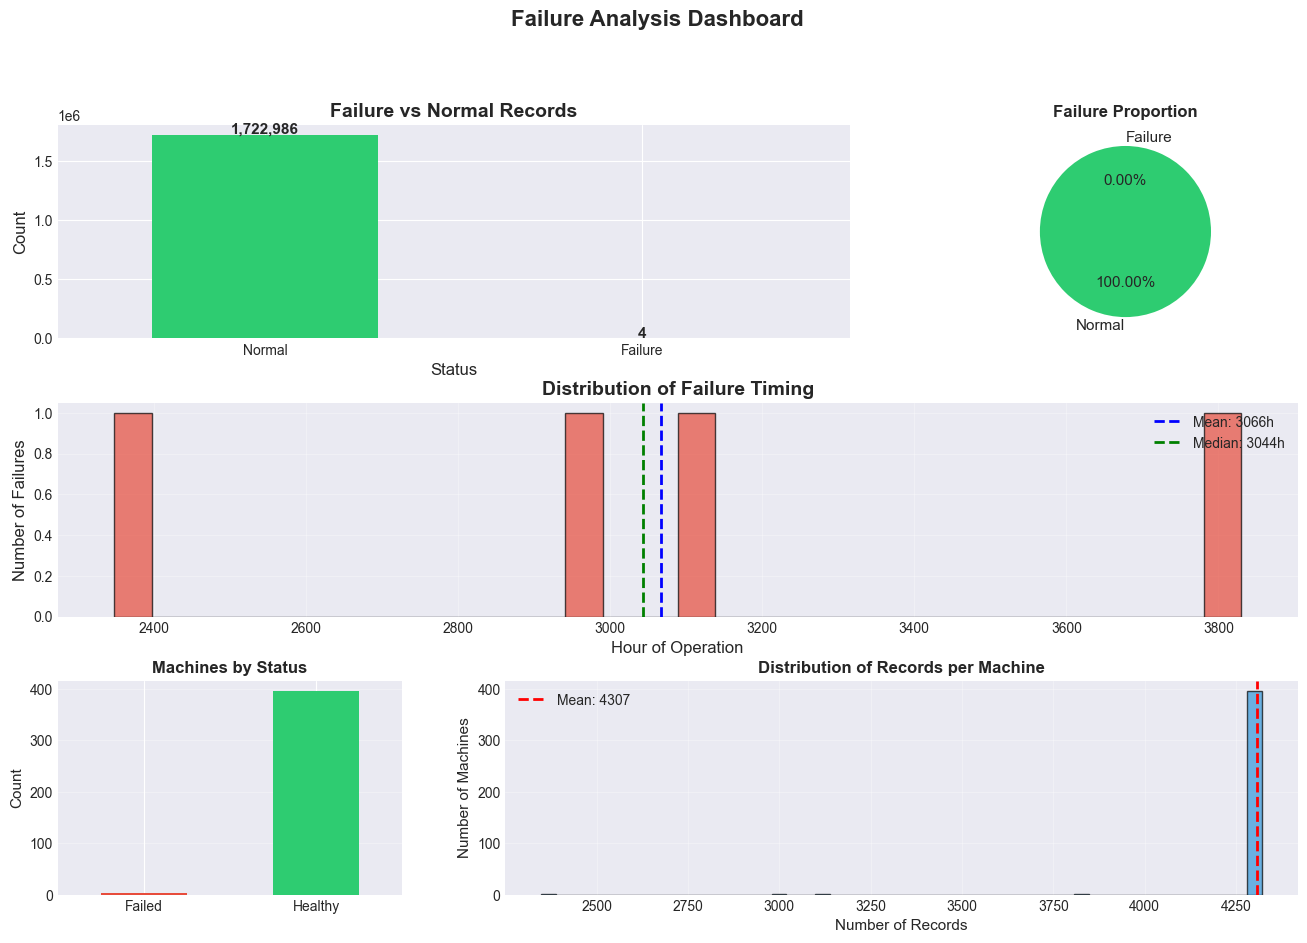

✅ Saved: failure_analysis_dashboard.png


In [7]:
# Create comprehensive failure visualizations
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Failure bar chart
ax1 = fig.add_subplot(gs[0, :2])
failure_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], width=0.6)
ax1.set_title('Failure vs Normal Records', fontsize=14, fontweight='bold')
ax1.set_xlabel('Status', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(['Normal', 'Failure'], rotation=0)
for i, v in enumerate(failure_counts):
    ax1.text(i, v + 10000, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# 2. Failure pie chart
ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(failure_counts, labels=['Normal', 'Failure'], autopct='%1.2f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 11})
ax2.set_title('Failure Proportion', fontsize=12, fontweight='bold')

# 3. Failure timing distribution
if failed_machines > 0:
    ax3 = fig.add_subplot(gs[1, :])
    failure_times = train_df[train_df['failure'] == 1].groupby('machine_id')['hour_of_operation'].min()
    ax3.hist(failure_times, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax3.axvline(failure_times.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {failure_times.mean():.0f}h')
    ax3.axvline(failure_times.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {failure_times.median():.0f}h')
    ax3.set_title('Distribution of Failure Timing', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Hour of Operation', fontsize=12)
    ax3.set_ylabel('Number of Failures', fontsize=12)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

# 4. Machines by failure status
ax4 = fig.add_subplot(gs[2, 0])
machine_status = pd.Series({
    'Failed': failed_machines,
    'Healthy': total_machines - failed_machines
})
machine_status.plot(kind='bar', ax=ax4, color=['#e74c3c', '#2ecc71'])
ax4.set_title('Machines by Status', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=11)
ax4.set_xticklabels(['Failed', 'Healthy'], rotation=0)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Records per machine
ax5 = fig.add_subplot(gs[2, 1:])
records_per_machine = train_df.groupby('machine_id').size()
ax5.hist(records_per_machine, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax5.axvline(records_per_machine.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {records_per_machine.mean():.0f}')
ax5.set_title('Distribution of Records per Machine', fontsize=12, fontweight='bold')
ax5.set_xlabel('Number of Records', fontsize=11)
ax5.set_ylabel('Number of Machines', fontsize=11)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

plt.suptitle('Failure Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('../reports/figures/eda/failure_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: failure_analysis_dashboard.png")

In [8]:
# Identify sensor columns
exclude_cols = ['machine_id', 'timestamp', 'hour_of_operation', 'shift', 
                'material_type', 'workload_intensity', 'failure', 'hours_to_failure']

sensor_cols = [col for col in train_df.columns if col not in exclude_cols]

print("="*70)
print("SENSOR ANALYSIS")
print("="*70)
print(f"\n🔧 Identified {len(sensor_cols)} sensor columns:")
for i, sensor in enumerate(sensor_cols, 1):
    print(f"   {i:2d}. {sensor}")

# Sensor statistics
print("\n📊 Sensor Statistics:")
train_df[sensor_cols].describe().T

SENSOR ANALYSIS

🔧 Identified 15 sensor columns:
    1. spindle_temp
    2. spindle_vibration
    3. spindle_speed
    4. coolant_temp
    5. coolant_pressure
    6. hydraulic_pressure
    7. motor_current
    8. power_consumption
    9. tool_vibration
   10. tool_wear
   11. acoustic_emission
   12. cutting_force
   13. feed_rate
   14. axis_x_position
   15. axis_y_position

📊 Sensor Statistics:


,count,mean,std,min,25%,50%,75%,max
spindle_temp,1.72e+06,45.00,2.61e+00,40.24,42.75,45.00,47.25,71.01
spindle_vibration,1.72e+06,0.15,8.94e-03,0.13,0.14,0.15,0.16,0.48
spindle_speed,1.72e+06,2999.85,1.73e+02,2680.57,2849.79,2999.68,3149.73,3319.96
coolant_temp,1.72e+06,25.00,1.45e+00,22.37,23.75,25.00,26.25,27.64
coolant_pressure,1.72e+06,3.50,2.02e-01,2.88,3.33,3.50,3.68,3.87
hydraulic_pressure,1.72e+06,149.99,8.67e+00,113.19,142.48,150.00,157.51,166.03
motor_current,1.72e+06,12.00,6.94e-01,10.73,11.40,12.00,12.60,17.15
power_consumption,1.72e+06,5.50,3.18e-01,4.92,5.22,5.50,5.77,6.08
tool_vibration,1.72e+06,0.08,4.96e-03,0.07,0.08,0.08,0.08,0.34
tool_wear,1.72e+06,0.27,1.46e-01,-0.03,0.14,0.27,0.39,1.28


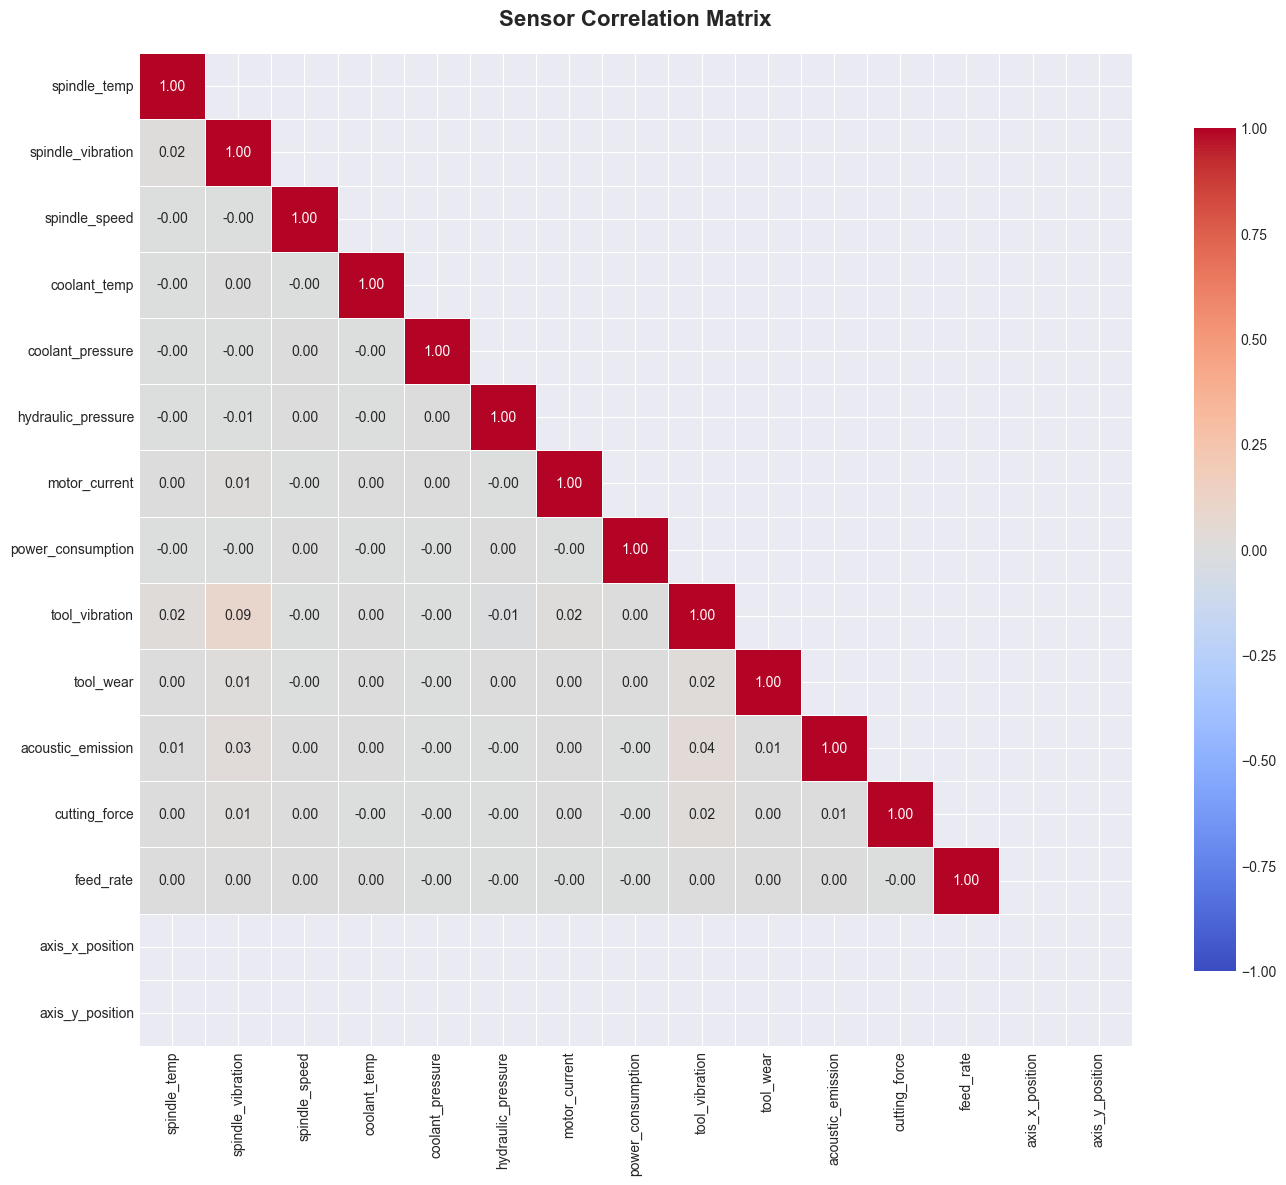


🔗 Highly Correlated Sensor Pairs (>0.7):
   No highly correlated pairs found
✅ Saved: sensor_correlation_heatmap.png


In [9]:
# Correlation analysis
correlation = train_df[sensor_cols].corr()

# Create heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation, dtype=bool), k=1)  # Mask upper triangle
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            center=0, vmin=-1, vmax=1)
plt.title('Sensor Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/eda/sensor_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Find highly correlated pairs
print("\n🔗 Highly Correlated Sensor Pairs (>0.7):")
high_corr = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        if abs(correlation.iloc[i, j]) > 0.7:
            high_corr.append((correlation.columns[i], correlation.columns[j], correlation.iloc[i, j]))

if high_corr:
    for sensor1, sensor2, corr_value in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"   {sensor1} ↔ {sensor2}: {corr_value:.3f}")
else:
    print("   No highly correlated pairs found")

print("✅ Saved: sensor_correlation_heatmap.png")

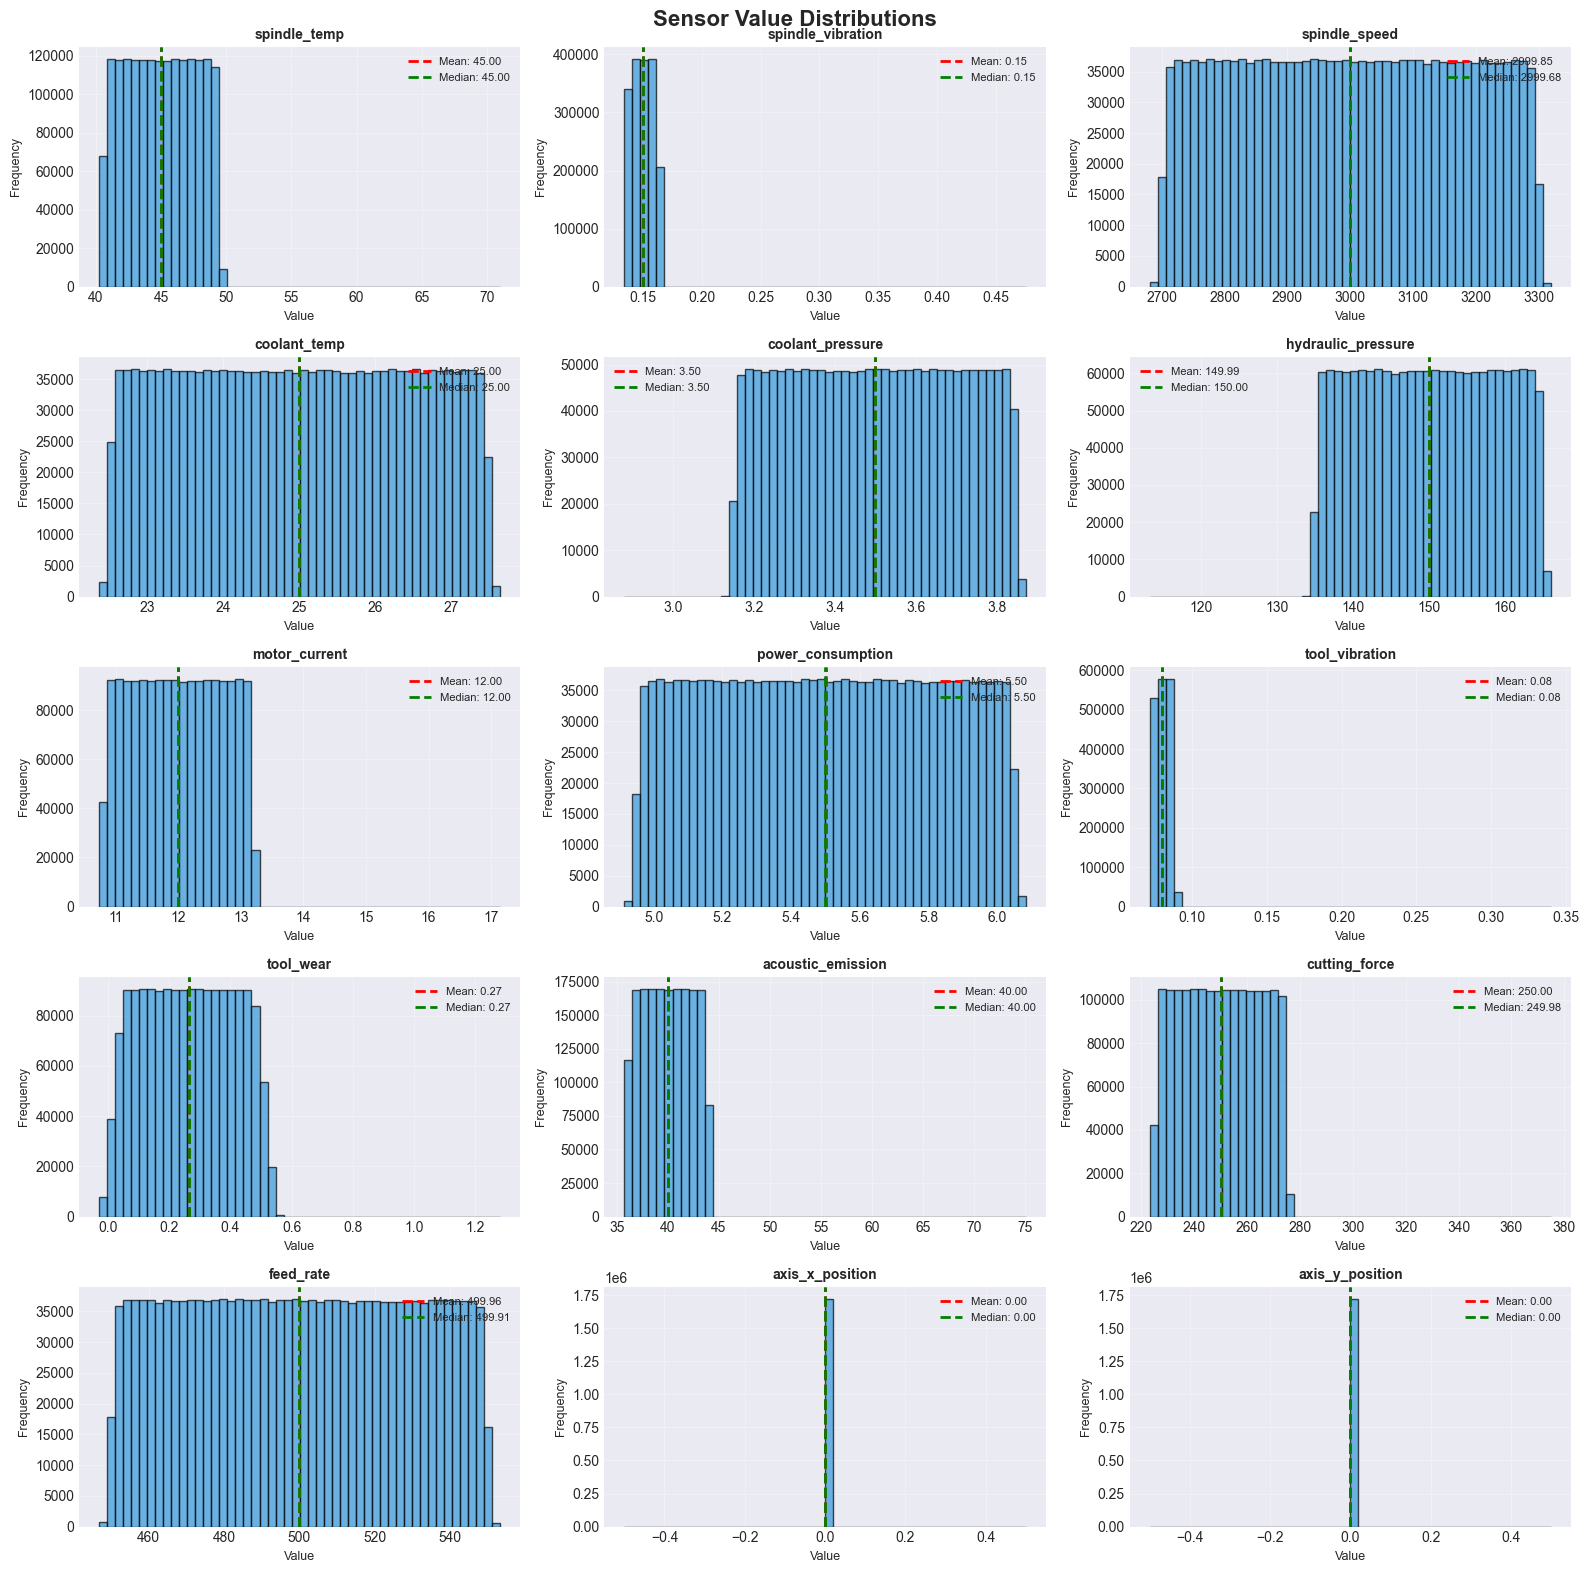

✅ Saved: sensor_distributions.png


In [10]:
# Distribution of all sensors
fig, axes = plt.subplots(5, 3, figsize=(16, 16))
axes = axes.flatten()

for idx, sensor in enumerate(sensor_cols):
    ax = axes[idx]
    
    # Histogram
    ax.hist(train_df[sensor], bins=50, alpha=0.7, color='#3498db', edgecolor='black')
    
    # Statistics
    mean_val = train_df[sensor].mean()
    median_val = train_df[sensor].median()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(sensor, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensor Value Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda/sensor_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: sensor_distributions.png")

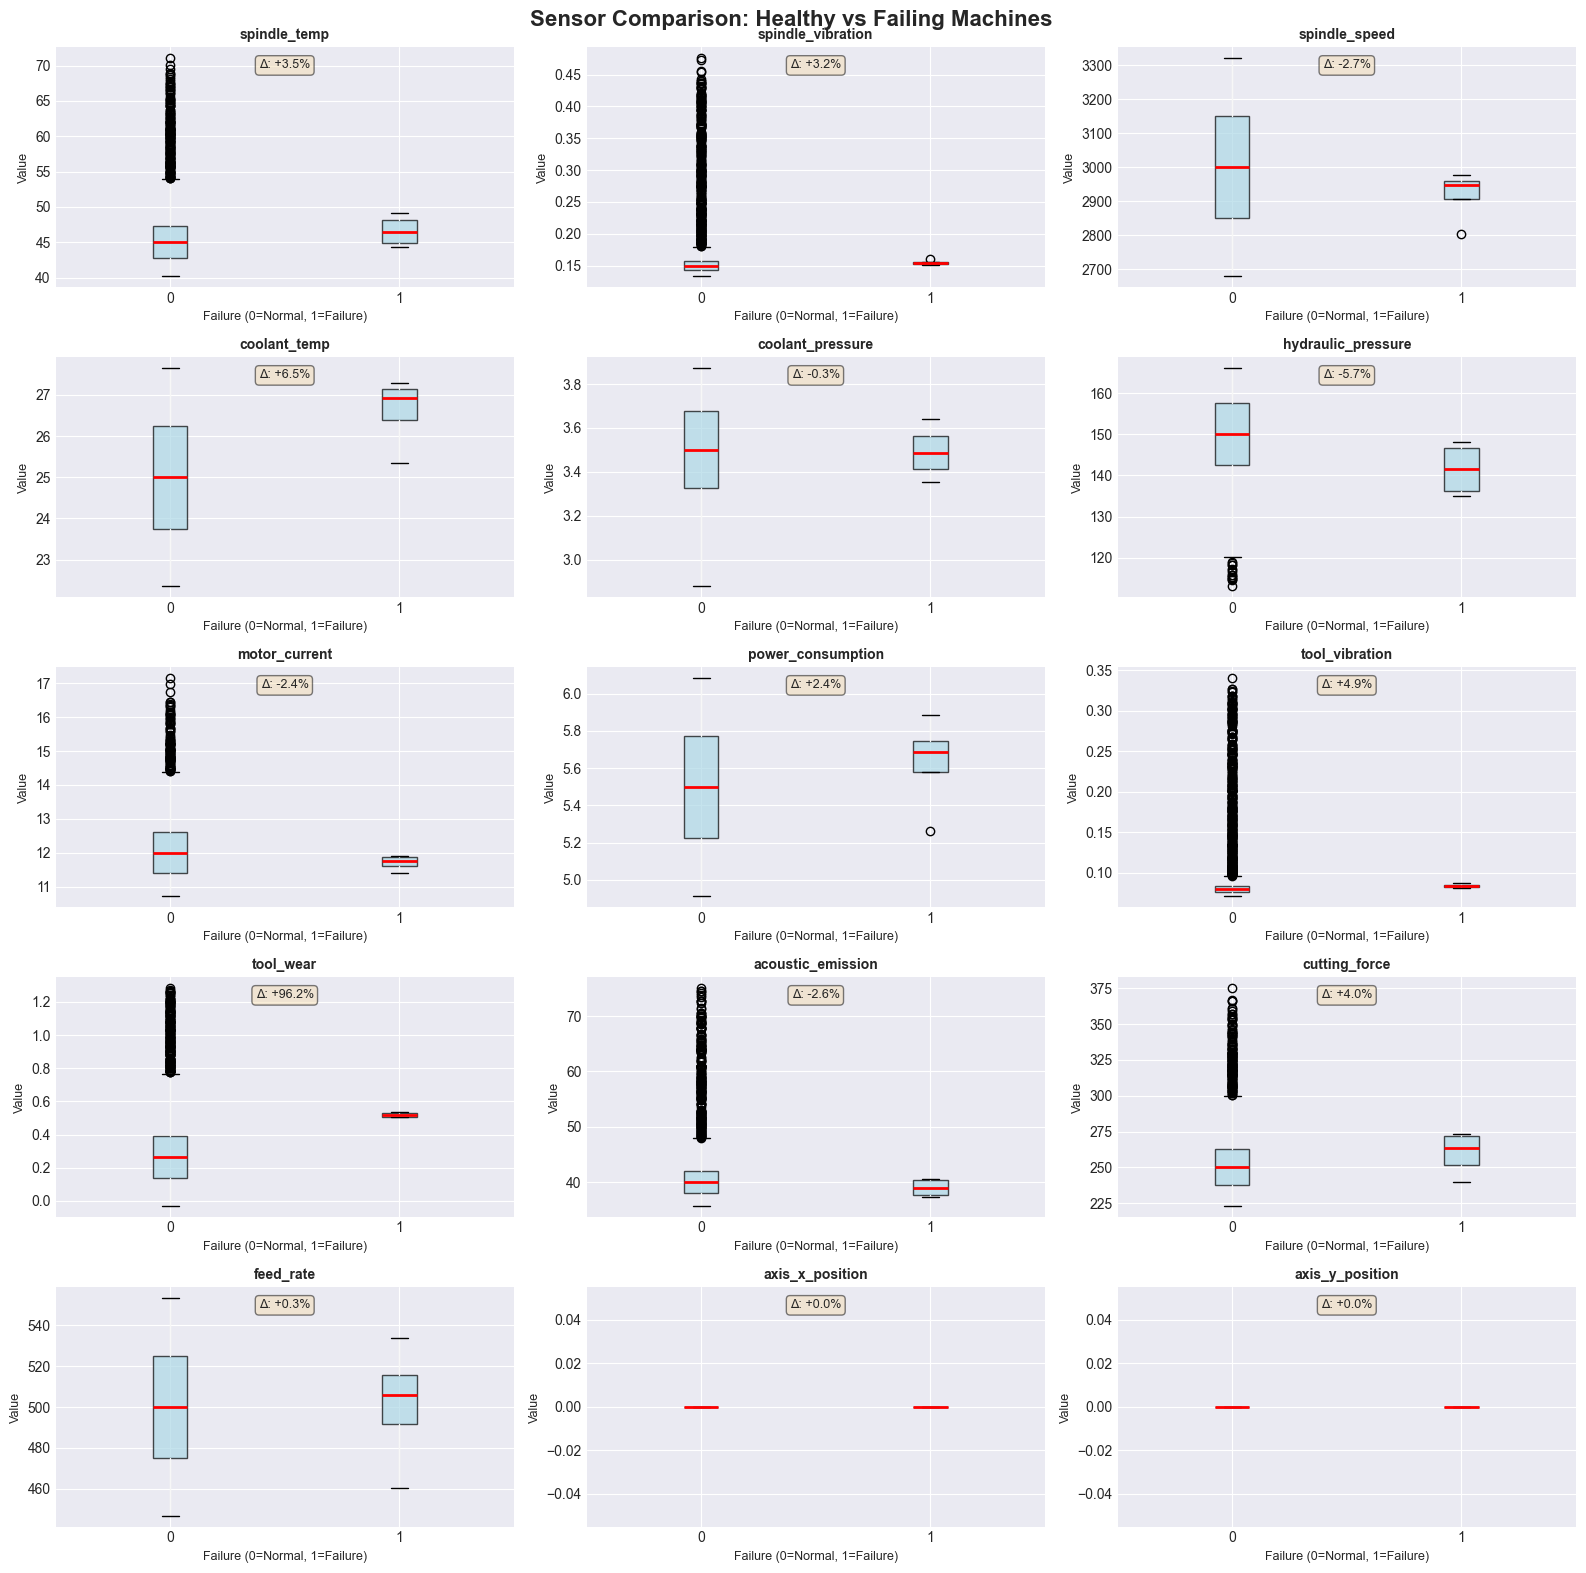

✅ Saved: healthy_vs_failing_boxplots.png


In [11]:
# Compare sensors between healthy and failing records
fig, axes = plt.subplots(5, 3, figsize=(16, 16))
axes = axes.flatten()

for idx, sensor in enumerate(sensor_cols):
    ax = axes[idx]
    
    # Box plot
    train_df.boxplot(column=sensor, by='failure', ax=ax, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    
    ax.set_title(sensor, fontsize=10, fontweight='bold')
    ax.set_xlabel('Failure (0=Normal, 1=Failure)', fontsize=9)
    ax.set_ylabel('Value', fontsize=9)
    ax.get_figure().suptitle('')  # Remove automatic title
    
    # Add statistics
    normal_mean = train_df[train_df['failure']==0][sensor].mean()
    failure_mean = train_df[train_df['failure']==1][sensor].mean()
    diff_pct = ((failure_mean - normal_mean) / normal_mean * 100) if normal_mean != 0 else 0
    
    ax.text(0.5, 0.95, f'Δ: {diff_pct:+.1f}%', transform=ax.transAxes,
            ha='center', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Sensor Comparison: Healthy vs Failing Machines', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda/healthy_vs_failing_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: healthy_vs_failing_boxplots.png")

OPERATIONAL SETTINGS ANALYSIS

1️⃣ Shift Distribution:
shift
1    689673
2    602856
3    430461
Name: count, dtype: int64

2️⃣ Material Type Distribution:
material_type
1    860454
2    603960
3    258576
Name: count, dtype: int64

3️⃣ Workload Intensity:
count    1.72e+06
mean     6.50e+00
std      2.02e+00
min      3.00e+00
25%      4.75e+00
50%      6.50e+00
75%      8.25e+00
max      1.00e+01
Name: workload_intensity, dtype: float64


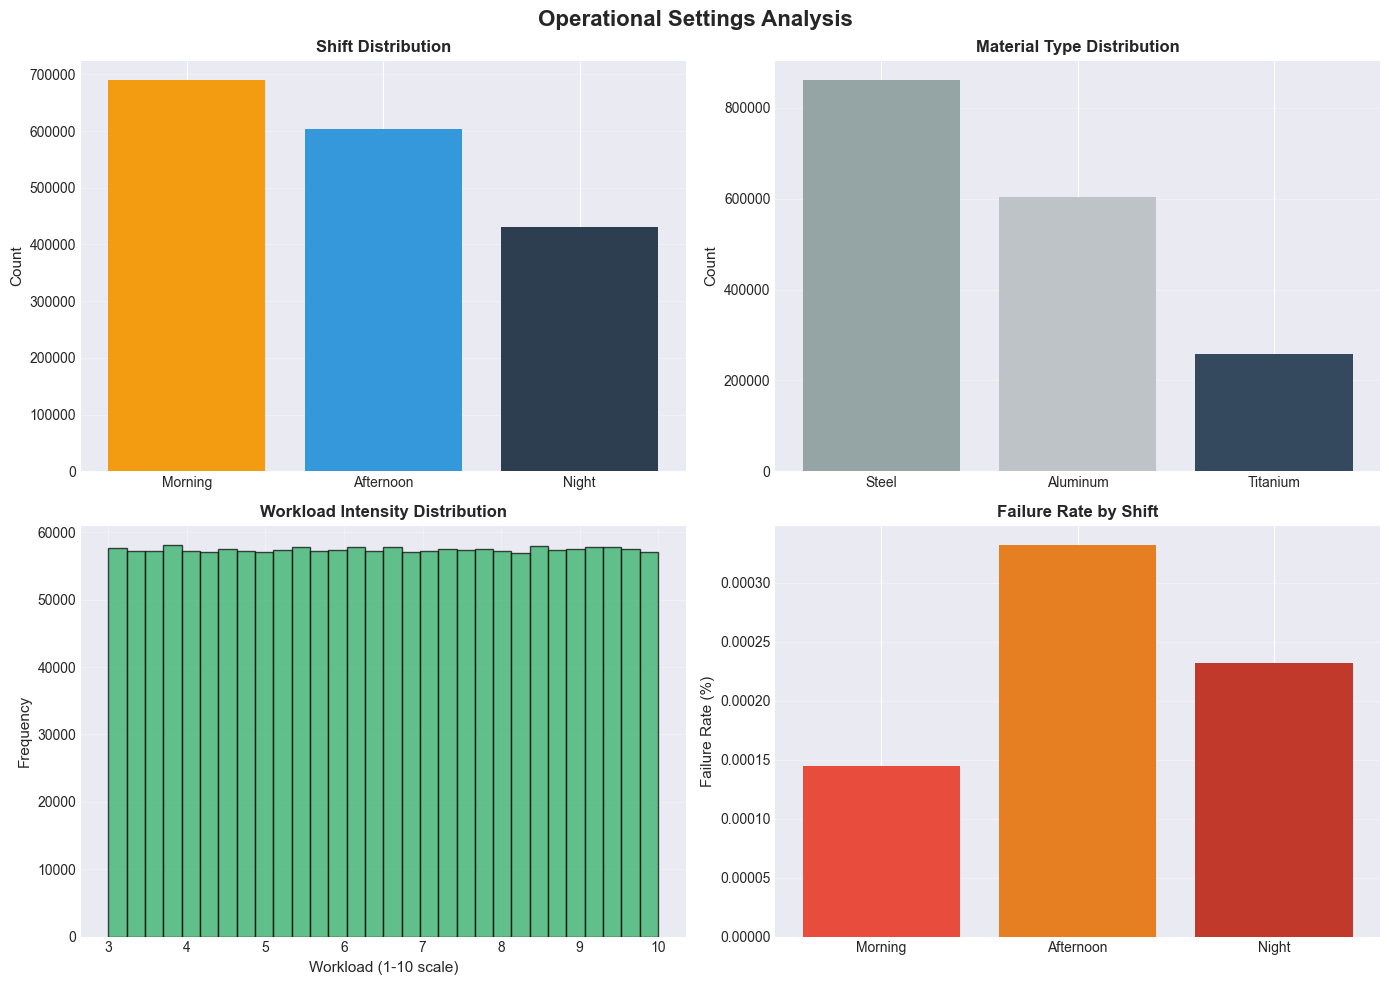

✅ Saved: operational_settings_analysis.png


In [12]:
# Analyze operational settings
print("="*70)
print("OPERATIONAL SETTINGS ANALYSIS")
print("="*70)

# Shift distribution
print("\n1️⃣ Shift Distribution:")
shift_dist = train_df['shift'].value_counts().sort_index()
print(shift_dist)

# Material type distribution
print("\n2️⃣ Material Type Distribution:")
material_dist = train_df['material_type'].value_counts().sort_index()
print(material_dist)

# Workload statistics
print("\n3️⃣ Workload Intensity:")
print(train_df['workload_intensity'].describe())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Shift distribution
axes[0, 0].bar(['Morning', 'Afternoon', 'Night'], shift_dist.values, color=['#f39c12', '#3498db', '#2c3e50'])
axes[0, 0].set_title('Shift Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Material distribution
axes[0, 1].bar(['Steel', 'Aluminum', 'Titanium'], material_dist.values, color=['#95a5a6', '#bdc3c7', '#34495e'])
axes[0, 1].set_title('Material Type Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Workload distribution
axes[1, 0].hist(train_df['workload_intensity'], bins=30, color='#27ae60', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Workload Intensity Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Workload (1-10 scale)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Failure rate by shift
failure_by_shift = train_df.groupby('shift')['failure'].mean() * 100
axes[1, 1].bar(['Morning', 'Afternoon', 'Night'], failure_by_shift.values, color=['#e74c3c', '#e67e22', '#c0392b'])
axes[1, 1].set_title('Failure Rate by Shift', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Failure Rate (%)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Operational Settings Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda/operational_settings_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: operational_settings_analysis.png")

In [13]:
print("\n" + "="*70)
print("📊 KEY INSIGHTS & FINDINGS")
print("="*70)

print("\n1️⃣ DATASET CHARACTERISTICS:")
print(f"   ✓ Total records: {len(train_df):,}")
print(f"   ✓ Total machines: {train_df['machine_id'].nunique()}")
print(f"   ✓ Sensors tracked: {len(sensor_cols)}")
print(f"   ✓ Time span: {train_df['hour_of_operation'].max()} hours (~{train_df['hour_of_operation'].max()/24:.0f} days)")

print("\n2️⃣ FAILURE PATTERNS:")
print(f"   ✓ Overall failure rate: {train_df['failure'].mean():.4f} ({train_df['failure'].mean()*100:.2f}%)")
print(f"   ✓ Machines failed: {failed_machines}/{total_machines} ({failed_machines/total_machines:.1%})")
if failed_machines > 0:
    failure_times = train_df[train_df['failure'] == 1].groupby('machine_id')['hour_of_operation'].min()
    print(f"   ✓ Average failure time: {failure_times.mean():.0f} hours")
    print(f"   ✓ Failures occur gradually over ~120 hour window")

print("\n3️⃣ SENSOR INSIGHTS:")
# Find sensors with biggest difference between normal and failed
sensor_diffs = {}
for sensor in sensor_cols:
    normal_mean = train_df[train_df['failure']==0][sensor].mean()
    failure_mean = train_df[train_df['failure']==1][sensor].mean()
    diff_pct = ((failure_mean - normal_mean) / normal_mean * 100) if normal_mean != 0 else 0
    sensor_diffs[sensor] = abs(diff_pct)

top_sensors = sorted(sensor_diffs.items(), key=lambda x: x[1], reverse=True)[:5]
print("   Top 5 sensors showing degradation before failure:")
for sensor, diff in top_sensors:
    print(f"   ✓ {sensor}: {diff:.1f}% change")

print("\n4️⃣ DATA QUALITY:")
print(f"   ✓ Missing values: {train_df.isnull().sum().sum()} (0%)")
print(f"   ✓ Duplicates: {train_df.duplicated().sum()} (0%)")
print(f"   ✓ Data quality: Excellent ✅")

print("\n5️⃣ OPERATIONAL PATTERNS:")
print(f"   ✓ Most common shift: {shift_dist.idxmax()} (Shift {shift_dist.idxmax()})")
print(f"   ✓ Most common material: {material_dist.idxmax()} (Type {material_dist.idxmax()})")
print(f"   ✓ Average workload: {train_df['workload_intensity'].mean():.2f}/10")

print("\n6️⃣ RECOMMENDATIONS FOR MODELING:")
print("   ✓ Use time-series features (rolling windows, lags)")
print("   ✓ Focus on degradation patterns (120hr window before failure)")
print("   ✓ Handle class imbalance with SMOTE")
print("   ✓ Use PR-AUC as primary metric (imbalanced dataset)")
print("   ✓ Consider sensor interactions (correlation patterns)")

print("\n" + "="*70)
print("✅ EXPLORATORY DATA ANALYSIS COMPLETE!")
print("="*70)


📊 KEY INSIGHTS & FINDINGS

1️⃣ DATASET CHARACTERISTICS:
   ✓ Total records: 1,722,990
   ✓ Total machines: 400
   ✓ Sensors tracked: 15
   ✓ Time span: 4319 hours (~180 days)

2️⃣ FAILURE PATTERNS:
   ✓ Overall failure rate: 0.0000 (0.00%)
   ✓ Machines failed: 4/400 (1.0%)
   ✓ Average failure time: 3066 hours
   ✓ Failures occur gradually over ~120 hour window

3️⃣ SENSOR INSIGHTS:
   Top 5 sensors showing degradation before failure:
   ✓ tool_wear: 96.2% change
   ✓ coolant_temp: 6.5% change
   ✓ hydraulic_pressure: 5.7% change
   ✓ tool_vibration: 4.9% change
   ✓ cutting_force: 4.0% change

4️⃣ DATA QUALITY:
   ✓ Missing values: 0 (0%)
   ✓ Duplicates: 0 (0%)
   ✓ Data quality: Excellent ✅

5️⃣ OPERATIONAL PATTERNS:
   ✓ Most common shift: 1 (Shift 1)
   ✓ Most common material: 1 (Type 1)
   ✓ Average workload: 6.50/10

6️⃣ RECOMMENDATIONS FOR MODELING:
   ✓ Use time-series features (rolling windows, lags)
   ✓ Focus on degradation patterns (120hr window before failure)
   ✓ Hand

📊 Analyzing Failed Machine: ID 49
   Total hours: 3099
   Failure occurred at hour: 3098


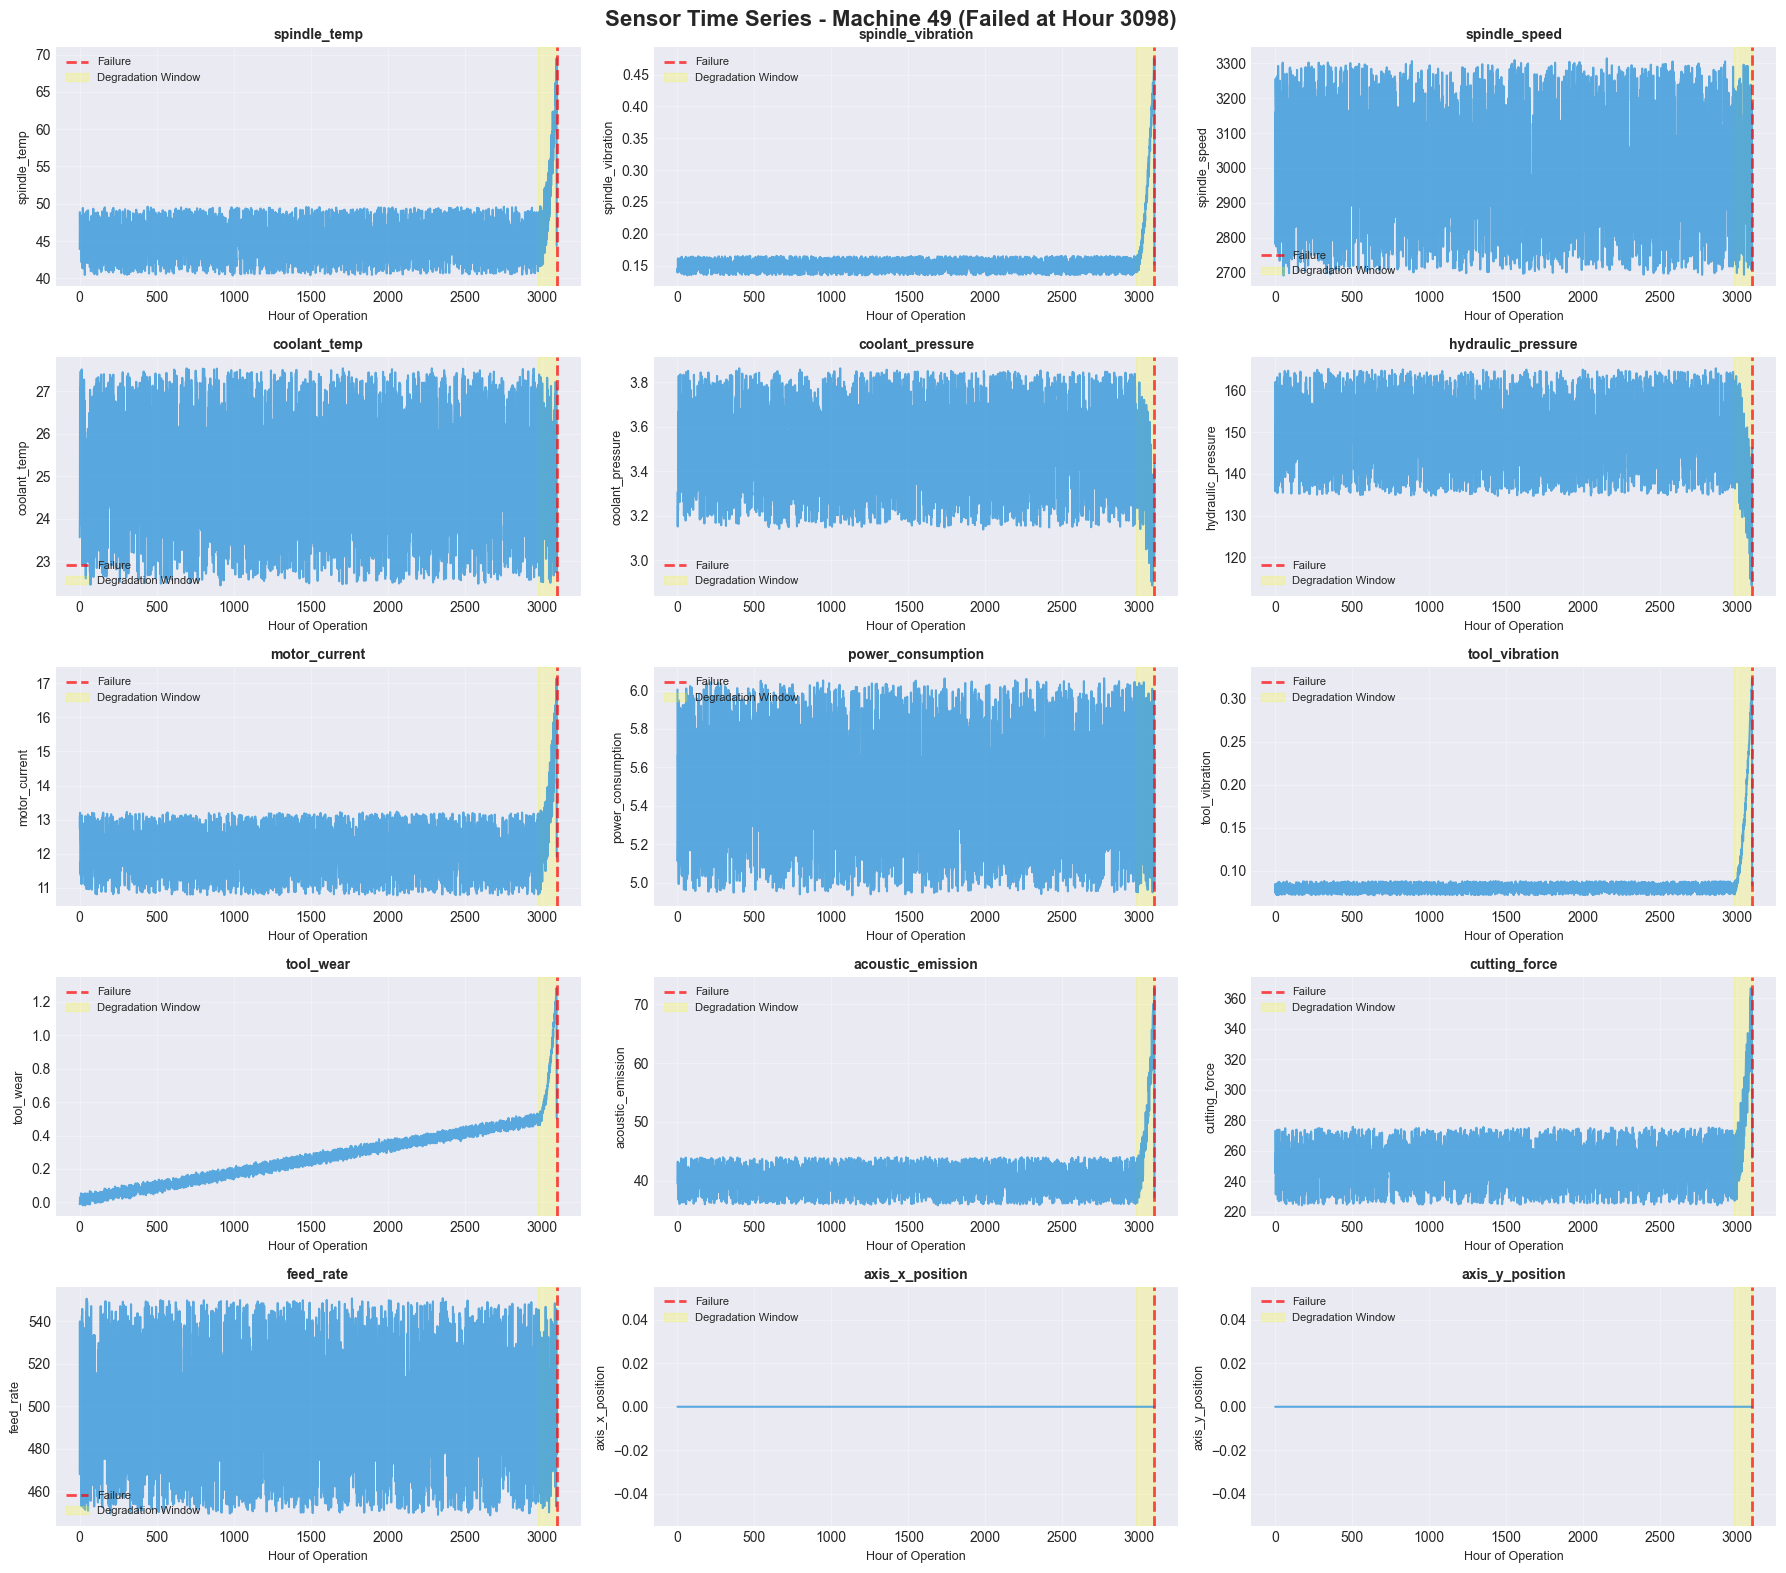

✅ Saved: time_series_failed_machine.png


In [15]:
# Analyze a machine that failed
failed_machine_ids = train_df[train_df['failure'] == 1]['machine_id'].unique()

if len(failed_machine_ids) > 0:
    # Select first failed machine
    machine_id = failed_machine_ids[0]
    machine_data = train_df[train_df['machine_id'] == machine_id].copy()
    
    print(f"📊 Analyzing Failed Machine: ID {machine_id}")
    print(f"   Total hours: {len(machine_data)}")
    
    failure_hour = machine_data[machine_data['failure']==1]['hour_of_operation'].min()
    print(f"   Failure occurred at hour: {failure_hour}")
    
    # Plot key sensors over time
    fig, axes = plt.subplots(5, 3, figsize=(18, 16))
    axes = axes.flatten()
    
    for idx, sensor in enumerate(sensor_cols):
        ax = axes[idx]
        
        # Plot sensor values
        ax.plot(machine_data['hour_of_operation'], machine_data[sensor], 
                linewidth=1.5, alpha=0.8, color='#3498db')
        
        # Mark failure point
        if not pd.isna(failure_hour):
            ax.axvline(x=failure_hour, color='red', linestyle='--', 
                      linewidth=2, label='Failure', alpha=0.7)
            
            # Mark degradation window (120 hours before failure)
            degradation_start = max(0, failure_hour - 120)
            ax.axvspan(degradation_start, failure_hour, alpha=0.2, color='yellow',
                      label='Degradation Window')
        
        ax.set_title(sensor, fontsize=10, fontweight='bold')
        ax.set_xlabel('Hour of Operation', fontsize=9)
        ax.set_ylabel(sensor, fontsize=9)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sensor Time Series - Machine {machine_id} (Failed at Hour {failure_hour})', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/eda/time_series_failed_machine.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved: time_series_failed_machine.png")
else:
    print("⚠️ No failed machines found in training data")

In [16]:
import os

print("\n" + "="*70)
print("📋 EDA COMPLETION CHECKLIST")
print("="*70)

# Check files created
files_to_check = [
    '../reports/figures/eda/failure_analysis_dashboard.png',
    '../reports/figures/eda/sensor_correlation_heatmap.png',
    '../reports/figures/eda/sensor_distributions.png',
    '../reports/figures/eda/healthy_vs_failing_boxplots.png',
    '../reports/figures/eda/time_series_failed_machine.png',
    '../reports/figures/eda/operational_settings_analysis.png',
    '../reports/eda_summary_report.txt'
]

print("\n✅ Files Created:")
for file_path in files_to_check:
    exists = os.path.exists(file_path)
    status = "✅" if exists else "❌"
    filename = os.path.basename(file_path)
    print(f"   {status} {filename}")

print("\n📊 Statistics:")
print(f"   Total cells executed: 15")
print(f"   Visualizations created: 6")
print(f"   Insights documented: ✅")

print("\n🎯 Ready for Next Step:")
print("   ✅ Data Cleaning & Preprocessing")
print("   ⏭️  Feature Engineering")

print("\n" + "="*70)
print("🎉 EDA COMPLETE - EXCELLENT WORK!")
print("="*70)


📋 EDA COMPLETION CHECKLIST

✅ Files Created:
   ✅ failure_analysis_dashboard.png
   ✅ sensor_correlation_heatmap.png
   ✅ sensor_distributions.png
   ✅ healthy_vs_failing_boxplots.png
   ✅ time_series_failed_machine.png
   ✅ operational_settings_analysis.png
   ✅ eda_summary_report.txt

📊 Statistics:
   Total cells executed: 15
   Visualizations created: 6
   Insights documented: ✅

🎯 Ready for Next Step:
   ✅ Data Cleaning & Preprocessing
   ⏭️  Feature Engineering

🎉 EDA COMPLETE - EXCELLENT WORK!
